# Dataset Type

In [10]:
DATASET_TYPE = "internal" # Options are "internal" or "downloaded"

# Load Data

In [11]:
# Import scikit-learn dataset library
from sklearn import datasets

if DATASET_TYPE == "internal":
  ann_data = datasets.load_breast_cancer()

  X = ann_data.data
  y = ann_data.target

  feature_names = ann_data.feature_names
  labels = ann_data.target_names
  cm_labels = labels

# OR: Download Dataset from file

In [12]:
import numpy as np
import pandas as pd

if DATASET_TYPE == "downloaded":

  ann_data = pd.read_csv('http://nrvis.com/data/mldata/breast-cancer-wisconsin_wdbc.csv')

  X = ann_data.iloc[:, 2:].to_numpy()
  y = ann_data.iloc[:, 1].to_numpy()
  feature_names = ann_data.columns
  labels = feature_names[1]
  cm_labels = ["malignant", "benign"]

  # Map labels from ['M', 'B'] to [0, 1] space
  y = np.where(y=='M', 0, 1)

# Explore the Data

In [13]:
# print the names of the features
print("Features: ", feature_names)

# print the label type of targets
print("Labels: ", labels)

Features:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Labels:  ['malignant' 'benign']


# Scale the data

In [14]:
# Image processing and pixel values - min-max scaling
# knn-clustering or regression which use distance metrics - standardization
# SVM or logistic regression or Neural Network which use gradiant descent - standardization
# decision tree and random forest - not distance based, hence no scaling is needed

# Normalize the data - Convert to range [0, 1]
# X = (X - np.min(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0))
# Standardize the data - Convert to a normal distribution with mean 0 and standard deviation of 1
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# Split the Data into Train and Test Sets

In [15]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

# Initialize the Model

In [16]:
from sklearn.neural_network import MLPClassifier

# More details about hyperparameters can be found here - 
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

mlp = MLPClassifier(hidden_layer_sizes=(8,8,8), activation='relu', solver='adam', max_iter=500)

# Train the Model

In [17]:
mlp.fit(X_train,y_train)

,hidden_layer_sizes,"(8, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,None


# Predict on Test Data

In [18]:
y_pred = mlp.predict(X_test)

# Evaluate on Test data

In [19]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy: how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(y_test, y_pred))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(y_test, y_pred))

Accuracy: 0.9736842105263158
Precision: 0.9583333333333334
Recall: 1.0


# Plot Confusion Matrix

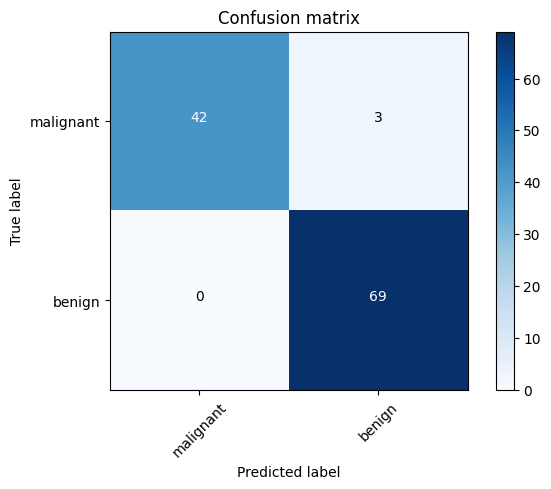

In [22]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm, cm_labels)  
plt.show()

# Overfitting and the bias-variance tradeoff

In [21]:
from ipywidgets import IntProgress
from IPython.display import display
import time

# High bias -> less complex model -> underfitting
# High variance -> more complex model -> overfitting
from sklearn.neural_network import MLPClassifier

# Extract a subset from train and test datasets to showcase the effects of under and overfitting using models of different sizes
X_train = X_train[:20, :]
y_train = y_train[:20]

X_test = X_test[:20, :]
y_test = y_test[:20]

# Less complex model - Less number of neurons
print("Training underfit model...")

mlp_underfit = MLPClassifier(hidden_layer_sizes=(1), alpha=0.0001, learning_rate_init=0.0001, activation='relu', solver='adam', max_iter=1000, shuffle=True, random_state=0)
mlp_underfit.fit(X_train, y_train)

# More complex model - More number of neurons 
print("Training overfit model...")
mlp_overfit = MLPClassifier(hidden_layer_sizes=(900), alpha=0.0001, learning_rate_init=0.0001, activation='relu', solver='adam', max_iter=1000, shuffle=True, random_state=0)
mlp_overfit.fit(X_train, y_train)

# Best fit model - Ideal number of neurons
print("Training best fit model...")
mlp_bestfit = MLPClassifier(hidden_layer_sizes=(8), alpha=0.0001, learning_rate_init=0.0001, activation='relu', solver='adam', max_iter=1000, shuffle=True, random_state=0)
mlp_bestfit.fit(X_train, y_train)

ModuleNotFoundError: No module named 'ipywidgets'

# Predict these models on Test Data

In [ ]:
y_pred_underfit = mlp_underfit.predict(X_test)
y_pred_overfit = mlp_overfit.predict(X_test)
y_pred_bestfit = mlp_bestfit.predict(X_test)

# Evaluate these models on Test data

In [ ]:
import numpy as np
from sklearn import metrics

print("<======== Errors on Train data ========>")
print(
      "Mean Absolute Error - Best fit model: ", metrics.mean_absolute_error(y_train, mlp_bestfit.predict(X_train)), 
      ", Underfit model: ", metrics.mean_absolute_error(y_train, mlp_underfit.predict(X_train)), 
      ", Overfit model: ", metrics.mean_absolute_error(y_train, mlp_overfit.predict(X_train)),
      )
print("Mean Squared Error - Best fit model: ", metrics.mean_squared_error(y_train, mlp_bestfit.predict(X_train)), 
      ", Underfit model: ", metrics.mean_squared_error(y_train, mlp_underfit.predict(X_train)), 
      ", Overfit model: ", metrics.mean_squared_error(y_train, mlp_overfit.predict(X_train)),
      )
print("Root Mean Squared Error - Best fit model: ", np.sqrt(metrics.mean_squared_error(y_train, mlp_bestfit.predict(X_train))),
      ", Underfit model: ", np.sqrt(metrics.mean_squared_error(y_train, mlp_underfit.predict(X_train))),
      ", Overfit model: ", np.sqrt(metrics.mean_squared_error(y_train, mlp_overfit.predict(X_train))),
      )

print("<======== Errors on Test data ========>")
print(
      "Mean Absolute Error - Best fit model: ", metrics.mean_absolute_error(y_test, y_pred_bestfit), 
      ", Underfit model: ", metrics.mean_absolute_error(y_test, y_pred_underfit), 
      ", Overfit model: ", metrics.mean_absolute_error(y_test, y_pred_overfit),
      )
print("Mean Squared Error - Best fit model: ", metrics.mean_squared_error(y_test, y_pred_bestfit), 
      ", Underfit model: ", metrics.mean_squared_error(y_test, y_pred_underfit), 
      ", Overfit model: ", metrics.mean_squared_error(y_test, y_pred_overfit),
      )
print("Root Mean Squared Error - Best fit model: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred_bestfit)),
      ", Underfit model: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred_underfit)),
      ", Overfit model: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred_overfit)),
      )

## Training errors 
Underfit model > Best fit model > Overfit model

##Testing errors 
Overfit model <> Underfit model > Best fit model

## Overfit model errors
Overfit Model Testing errors > Overfit Model Training errors

## Bestfit model errors
Testing errors ~ Training errors